In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)

2.19.0


In [4]:
observations=1000000
xs = np.random.uniform(low=-10,high=10, size=(observations,1))
zs = np.random.uniform(low=-10,high=10, size=(observations,1))
inputs=np.column_stack((xs,zs))
print(inputs.shape)

(1000000, 2)


In [5]:
noise = np.random.uniform(low=-1,high=1, size=(observations,1))
targets = 2*xs - 3*zs + 5 + noise
np.savez('TF_dataset', inputs=inputs, targets=targets)
print(targets.shape)

(1000000, 1)


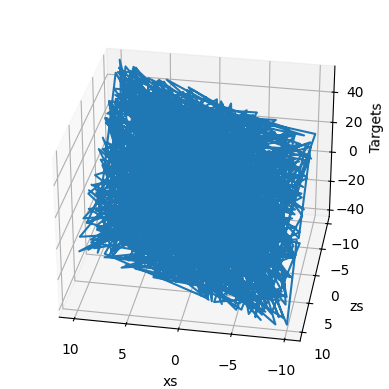

In [7]:
targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)

# Sample a smaller subset of data for plotting
sample_size = 1000
sample_indices = np.random.choice(observations, sample_size, replace=False)

xs_sample = xs[sample_indices]
zs_sample = zs[sample_indices]
targets_sample = targets[sample_indices]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs_sample, zs_sample, targets_sample)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)
plt.show()

In [22]:
init_range = 0.1
weights = np.random.uniform(low=-init_range,high=init_range, size=(2,1))
biases = np.random.uniform(low=-init_range,high=init_range, size=1)
print(weights,biases)

[[-0.04165744]
 [ 0.04464595]] [0.08474481]


In [32]:
targets = targets.reshape(observations,1)
eta = 1
for i in range (100):
  outputs = np.dot(inputs, weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas ** 2)/2/observations
  print(loss)

  deltas_scaled = deltas/observations
  weights = weights - eta * np.dot(inputs.T, deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)

/tmp/ipykernel_8334/3074232521.py:7: RuntimeWarning: overflow encountered in square
  loss = np.sum(deltas ** 2)/2/observations
/tmp/ipykernel_8334/3074232521.py:4: RuntimeWarning: overflow encountered in add
  outputs = np.dot(inputs, weights) + biases
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


inf
inf
inf
inf
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan


In [ ]:
print (weights, biases)

[[ 2.00692224]
 [-2.99504527]] [4.3310583]


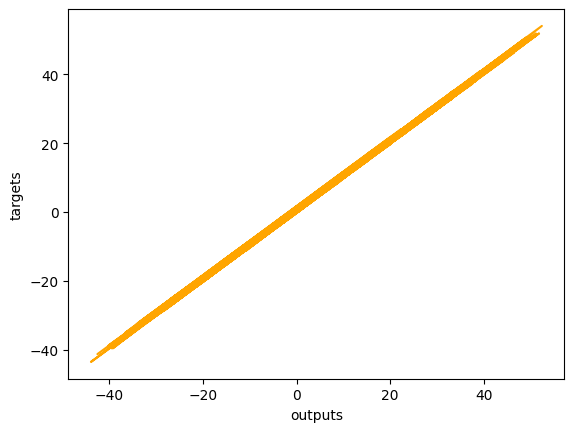

In [ ]:
plt.plot(outputs, targets, color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()